---
tags: [algorithm, encoding, primitive]
---

# Möttönen振幅エンコーディング

**振幅エンコーディング**とは、与えられた単位ノルムの複素ベクトル$a \in \mathbb{C}^{2^n}$に対して、$|0\rangle^{\otimes n}$から$n$量子ビットの状態

$$
|\psi\rangle \;=\; \sum_{i=0}^{2^n - 1} a_i \, |i\rangle
$$

を準備する操作です。古典データを量子状態として読み込むあらゆるアルゴリズム — HHL系の線形方程式ソルバー、カーネル法、多くの量子シミュレーションプロトコルなど — の入口にあたります。Qamomileは`qamomile.circuit.algorithm.state_preparation`の下に、Möttönen, Vartiainen, Bergholm, Salomaaの一様制御回転構成 {cite:p}`10.48550/arXiv.quant-ph/0407010` に基づいたSDK移植可能な実装を提供しています (元論文は任意状態 $|a\rangle \to |b\rangle$ の変換を扱っていますが、実装では入力を $|0\rangle^{\otimes n}$ に固定した state-preparation 半分だけを emit します — 詳細は §3 のリソース推定を参照)。

この構成は2段階からなります:

1. $n$個の**一様制御$R_y$ゲート**のカスケード。基底状態に振幅$|a_i|$を分配します。実数（符号付き）振幅ベクトルにはこの段だけで十分です。
2. **一様制御$R_z$ゲート**の2段目のカスケード。相対位相を復元します。入力に非ゼロの虚部が含まれる場合のみ発行されます。

各一様制御回転は、Möttönen-VartiainenのGray符号レシピを使って基本的な`RY` / `RZ`と`CNOT`ゲートに分解されます。総コストは次のとおりです:

| 段 | 実数入力 | 複素入力 |
|---|---:|---:|
| $R_y$回転 | $2^n - 1$ | $2^n - 1$ |
| $R_z$回転 | $0$ | $2^n - 1$ |
| `CNOT` | $2^n - 2$ | $2 (2^n - 2)$ |

このチュートリアルではまず最も単純な使い方 (§1, §2) を見て、その後 IR の可視化とリソース推定 (§3)、ランタイム再バインドが効く角度 API (§4)、そしてより大きいカーネルへの組み込み (§5) と進みます。

> ⚠️ **前提条件: 入力量子ビットは全ゼロ状態** $|0\rangle^{\otimes n}$ **でなければなりません**。Qamomileの`amplitude_encoding(...)` / `amplitude_encoding_from_angles(...)`は$|0\rangle^{\otimes n}$から目標状態$|\psi\rangle$へ写すユニタリだけを emit します (Möttönen の一般構成は任意入力にも拡張できますが、実装は state-preparation の片側に特化しています)。それ以外の入力に適用すると別の出力 (目標振幅ベクトルとは無関係) が出てきます。Qamomileはruntimeで量子ビットの状態を追跡しないため、`qmc.qubit_array(n, ...)`の直後、他のゲートがレジスタに触れる前に呼び出す責任は呼び出し側にあります。

In [1]:
import numpy as np
from qiskit.quantum_info import Statevector

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.circuit.algorithm import (
    amplitude_encoding,
    amplitude_encoding_from_angles,
)
from qamomile.linalg import (
    compute_mottonen_amplitude_encoding_ry_angles,
    compute_mottonen_amplitude_encoding_rz_angles,
)
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()
executor = transpiler.executor()

ATOL_STATEVECTOR = 1e-8
ATOL_SHOT = 0.05  # 8192 shots, p(1-p)/N に対しおよそ5σ


def fidelity(prepared: np.ndarray, target: np.ndarray) -> float:
    """位相不変なフィデリティ ``|<prepared|target>|^2``。"""
    return float(np.abs(np.vdot(prepared, target)) ** 2)


def normalize(amps: list[float] | list[complex]) -> np.ndarray:
    """単位ノルム化した *amps* のコピー（任意の要素が複素数なら複素dtype）。"""
    if any(isinstance(x, complex) for x in amps):
        arr = np.asarray(amps, dtype=complex)
    else:
        arr = np.asarray(amps, dtype=float)
    return arr / np.linalg.norm(arr)


def statevector_of(kernel: qmc.QKernel, **bindings) -> np.ndarray:
    """*kernel*をQiskitのstatevectorシミュレータで実行してデータを返す。"""
    qc = transpiler.to_circuit(kernel, bindings=bindings or None)
    return Statevector.from_instruction(
        qc.remove_final_measurements(inplace=False)
    ).data

## 1. もっとも単純な呼び出し — 具体的な実数振幅

`amplitude_encoding(qubits, amplitudes)`が日常的な入口です。Pythonのシーケンスやnumpy配列を受け取り、自動的に正規化して対応する状態を準備します。

最初の確認として、未正規化のベクトル$a = (1, 2, 3, 4)$を2量子ビットレジスタにエンコードし、シミュレータの状態ベクトルを読み戻して、正規化されたターゲットと（位相を除いて）一致することを assert します。

In [2]:
amps_real = [1.0, 2.0, 3.0, 4.0]


@qmc.qkernel
def prepare_real() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding(q, amps_real)
    return qmc.measure(q)


sv = statevector_of(prepare_real)
expected = normalize(amps_real)
print(f"prepared      = {np.round(sv, 4)}")
print(f"target (norm) = {np.round(expected, 4)}")
print(f"fidelity      = {fidelity(sv, expected):.6f}")
assert np.isclose(fidelity(sv, expected), 1.0, atol=ATOL_STATEVECTOR), (
    "実振幅エンコーディングのfidelityが落ちています"
)

prepared      = [0.1826+0.j 0.3651+0.j 0.5477+0.j 0.7303+0.j]
target (norm) = [0.1826 0.3651 0.5477 0.7303]
fidelity      = 1.000000


負の実数振幅は magnitude 段を自然に通過します — 葉レベルの$R_y$角は符号付きの`arctan2`として取られるため、追加の位相段なしで符号が捕捉されます。したがって状態$a = (1, -1, 1, -1)$は`RY`と`CNOT`のみで準備されます。

In [3]:
amps_signed = [1.0, -1.0, 1.0, -1.0]


@qmc.qkernel
def prepare_signed() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding(q, amps_signed)
    return qmc.measure(q)


sv = statevector_of(prepare_signed)
expected = normalize(amps_signed)
print(f"fidelity (signed) = {fidelity(sv, expected):.6f}")
assert np.isclose(fidelity(sv, expected), 1.0, atol=ATOL_STATEVECTOR), (
    "符号付き実数エンコーディングのfidelityが落ちています"
)

fidelity (signed) = 1.000000


## 2. 複素振幅

同じAPIが複素入力を受け取ります。少なくとも1つの要素が非ゼロの虚部を持つ場合、実装は2段（Ry + Rz）構成に自動的に切り替わります。虚部が恒等的にゼロの複素ベクトルは、より安価な実数経路に静かに変換されます。

$a = (1, 1+i, 1-i, 2i)$ — 一般的な複素2量子ビット状態 — をエンコードし、結果の状態ベクトルが（大域位相を除いて）一致することをassertします。

In [4]:
amps_complex = [1 + 0j, 1 + 1j, 1 - 1j, 0 + 2j]


@qmc.qkernel
def prepare_complex() -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding(q, amps_complex)
    return qmc.measure(q)


sv = statevector_of(prepare_complex)
expected = normalize(amps_complex)
print(f"fidelity (complex) = {fidelity(sv, expected):.6f}")
assert np.isclose(fidelity(sv, expected), 1.0, atol=ATOL_STATEVECTOR), (
    "複素エンコーディングのfidelityが落ちています"
)

fidelity (complex) = 1.000000


## 3. 可視化とリソース推定

### 回路の可視化 — `kernel.draw()`

`kernel.draw(fold_loops=False)` でカーネルのIRを描画できます。`amplitude_encoding`を使ったカーネルでは、エンコード処理がまるごと単一の `MottonenAmplitudeEncoding` コンポジットゲートとしてIRに残るため、デフォルトでは中身が見えない大きい1ブロックとして表示されます。

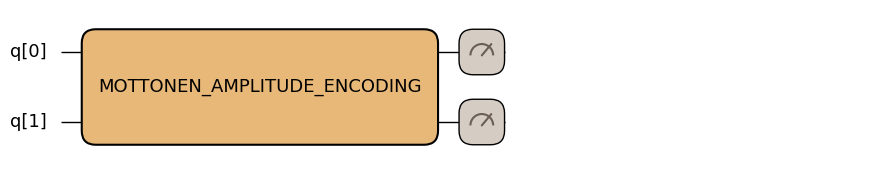

In [5]:
prepare_real.draw(fold_loops=False)

中身を覗くには `expand_composite=True` を渡します。コンポジットゲートが展開され、内部の基本 `RY` / `RZ` / `CNOT` ゲートが見えるようになります。

実数経路では `RY` と `CNOT` のみが現れます:

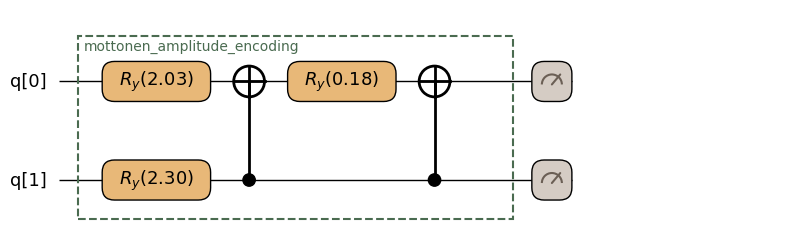

In [6]:
prepare_real.draw(fold_loops=False, expand_composite=True)

複素経路では同じ位置に `RZ` ゲートが追加で現れることが確認できます:

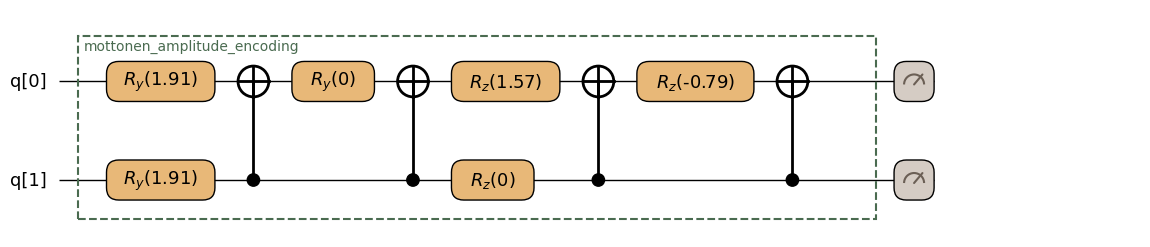

In [7]:
prepare_complex.draw(fold_loops=False, expand_composite=True)

### リソース推定 — 論文の公式値との照合

Möttönen, Vartiainen, Bergholm, Salomaa {cite:p}`10.48550/arXiv.quant-ph/0407010` の Section II は、$k$個のcontrolを持つuniformly controlled rotationを $2^k$個の基本回転と $2^k$個のCNOTに分解するGray符号レシピを与えています (Section II, Fig. 2 と Eq. (2) 直後の段落 — 論文側ではLemma / Theorem番号は付いていません)。振幅エンコーディングは $k = 0, 1, \ldots, n-1$ の $n$ 個のUC回転をカスケード接続するため、stage $0$ は uncontrolled (CNOT なし) として、1 cascade あたり次の値を実現します:

| 入力     | 回転数               | CNOT数                  |
|----------|---------------------:|-----------------------:|
| 実数     | $2^n - 1$            | $2^n - 2$              |
| 複素数   | $2 \cdot (2^n - 1)$  | $2 \cdot (2^n - 2)$    |

> **論文のアブストラクトとの差異について**: 論文アブストラクトは $2^{n+2} - 5$ rotations + $2^{n+2} - 4n - 4$ CNOTs という値を提示していますが、これは**任意入力 $|a\rangle$ から任意出力 $|b\rangle$ への state-to-state 変換** ($|a\rangle \to |e_1\rangle \to |b\rangle$ の両側) のコストです。Qamomile の `amplitude_encoding` は $|0\rangle^{\otimes n} \to |\psi\rangle$ の片側だけを emit するので、上の表のとおり約半分のコストになります。なお Qamomile の実装は cascade 間の CNOT cancellation はかけていません — 各 stage ごとの素直な分解で留めています。

`kernel.estimate_resources()` がこの値を正確に報告することを、複数のレジスタサイズに対して確認します。これは `MottonenAmplitudeEncoding._resources()` のメタデータを直接見るのではなく、IRを歩いてコンポジットゲートを解決するフルの推定経路を通るため、テスト的にもより強い保証になります。

In [8]:
def make_real_kernel(n: int) -> qmc.QKernel:
    """``n``量子ビットで実振幅Möttönen経路を走らせるカーネル。"""
    real_amps = np.ones(2**n).tolist()

    @qmc.qkernel
    def kernel() -> qmc.Vector[qmc.Bit]:
        q = qmc.qubit_array(n, "q")
        q = amplitude_encoding(q, real_amps)
        return qmc.measure(q)

    return kernel


def make_complex_kernel(n: int) -> qmc.QKernel:
    """複素 (Ry+Rz) Möttönen経路を走らせるカーネル。"""
    cplx_amps = (np.ones(2**n) + 1j * np.arange(2**n)).tolist()

    @qmc.qkernel
    def kernel() -> qmc.Vector[qmc.Bit]:
        q = qmc.qubit_array(n, "q")
        q = amplitude_encoding(q, cplx_amps)
        return qmc.measure(q)

    return kernel


print(f"{'n':>3s} | {'real(rot/CNOT)':>16s} | {'complex(rot/CNOT)':>20s}")
print(f"{'---':>3s} | {'---':>16s} | {'---':>20s}")
for n in (2, 3, 4, 5):
    er = make_real_kernel(n).estimate_resources()
    ec = make_complex_kernel(n).estimate_resources()
    rot_real, cnot_real = int(er.gates.rotation_gates), int(er.gates.two_qubit)
    rot_cplx, cnot_cplx = int(ec.gates.rotation_gates), int(ec.gates.two_qubit)
    print(
        f"{n:>3d} | {f'{rot_real} / {cnot_real}':>16s} | {f'{rot_cplx} / {cnot_cplx}':>20s}"
    )

    # Möttönen-Vartiainen の閉形式を直接 assert:
    assert rot_real == 2**n - 1, f"実数の回転数が公式値と不一致 (n={n})"
    assert cnot_real == 2**n - 2, f"実数のCNOT数が公式値と不一致 (n={n})"
    assert rot_cplx == 2 * (2**n - 1), f"複素の回転数が公式値と不一致 (n={n})"
    assert cnot_cplx == 2 * (2**n - 2), f"複素のCNOT数が公式値と不一致 (n={n})"

  n |   real(rot/CNOT) |    complex(rot/CNOT)
--- |              --- |                  ---


  2 |            3 / 2 |                6 / 4
  3 |            7 / 6 |              14 / 12
  4 |          15 / 14 |              30 / 28
  5 |          31 / 30 |              62 / 60


回転数も CNOT 数も $n$ について $O(2^n)$ で増加します — 振幅エンコーディングは多量子ビットで本質的に高価なオペレーションです。

## 4. ランタイム再バインドが効く角度API

state_preparationパッケージはユーザ向けに大きく分けて2つのエントリポイントを提供します:

- `amplitude_encoding(q, amplitudes)` — §1〜§3 で見てきた**振幅ベース**の入口。コンパイル時に振幅から角度を計算し、IR に単一の `MottonenAmplitudeEncoding` コンポジットゲートを残します。
- `amplitude_encoding_from_angles(q, ry_angles, rz_angles=None)` — Möttönen角度を**事前に計算済み**で渡す**角度ベース**の入口。同じコンパイル済み回路を runtime で異なる振幅ベクトルに何度も再バインドできるのはこちらだけです (ハイブリッド最適化ループ、パラメータ掃引向け)。

`amplitude_encoding` はさらに、振幅の渡し方として (a) 具体シーケンスを直接渡す形と、(b) `Vector[Float]` カーネルパラメータに `bindings={...}` で値を流し込む形をサポートします。以下のサブセクションで、まだ §1〜§3 で見ていない (b) と `amplitude_encoding_from_angles` を順に動かして見せます。

### 4.1 `amplitude_encoding` に bound `Vector[Float]` パラメータを渡す

振幅をマジックナンバーとしてカーネル内に書き込みたくない (掃引したい、ドキュメント目的でパラメータとして見せたい等) 場合、`amps: Vector[Float]` をカーネルパラメータとして宣言し、`bindings={"amps": [...]}` で値を流し込めます。コンパイル時にバインド済み具体データが読まれるため、IRの形は §1 の具体シーケンス版と同一です。実数のみ対応 (`Vector[Float]`は複素数を運べないため)。

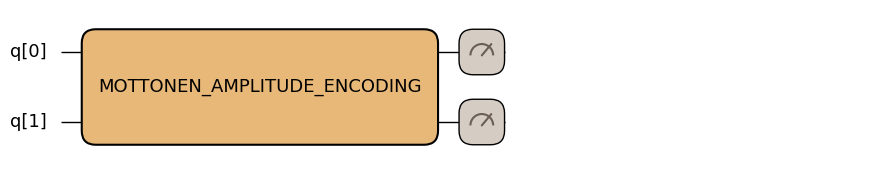

In [9]:
@qmc.qkernel
def prepare_via_binding(amps: qmc.Vector[qmc.Float]) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding(q, amps)
    return qmc.measure(q)


prepare_via_binding.draw(fold_loops=False, amps=[1.0, 2.0, 3.0, 4.0])

In [10]:
sv = statevector_of(prepare_via_binding, amps=[1.0, 2.0, 3.0, 4.0])
print(
    f"fidelity (bound Vector[Float]) = {fidelity(sv, normalize([1.0, 2.0, 3.0, 4.0])):.6f}"
)
assert np.isclose(
    fidelity(sv, normalize([1.0, 2.0, 3.0, 4.0])), 1.0, atol=ATOL_STATEVECTOR
)

fidelity (bound Vector[Float]) = 1.000000


`parameters=["amps"]`で `amps` を symbolic に残そうとすると、方向付きエラーで拒否されます — 角度計算（`atan2(|a_1|, |a_0|)`など）には具体的な数値が必要なので、ランタイムへ遅延させることは本質的にできません。エラーメッセージはランタイムケース用に `amplitude_encoding_from_angles` を指し示します。

In [11]:
try:
    transpiler.transpile(prepare_via_binding, parameters=["amps"])
except ValueError as exc:
    print(f"ValueError: {exc}")
    raised = True
else:
    raised = False
assert raised, "ampsをruntime parameterにすると ValueError が出るはず"

ValueError: amplitude_encoding received a Vector[Float] handle without concrete values at trace time. Bind it via transpiler.transpile(kernel, bindings={...}) for compile-time amplitudes, or use amplitude_encoding_from_angles with parameters=[...] for runtime-parametric angles.


### 4.2 `amplitude_encoding_from_angles` — 1度コンパイルして何度も再バインド

`amplitude_encoding_from_angles` は、1つのコンパイル済み回路を異なる振幅ベクトルに run-time で再バインドできる**唯一**のパスです。`compute_mottonen_amplitude_encoding_*_angles` ヘルパーで角度を古典的に事前計算し、`parameters=[...]`で1度transpileしておき、反復ごとに新しいバインディングでサンプリングします。複素入力にも対応します (`rz_angles` を渡す)。

注意: この経路は `MottonenAmplitudeEncoding` コンポジットゲートのラッピングをスキップし、基本 `RY` / `RZ` / `CNOT` ゲートを直接 IR に発行します。リソース推定は高レベルopではなく基本ゲート列を見ることになります。

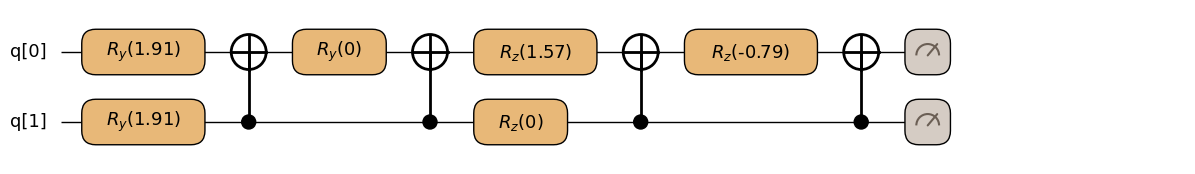

In [12]:
@qmc.qkernel
def prepare_from_angles(
    ry_a: qmc.Vector[qmc.Float], rz_a: qmc.Vector[qmc.Float]
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding_from_angles(q, ry_a, rz_a)
    return qmc.measure(q)


prepare_from_angles.draw(
    fold_loops=False,
    ry_a=compute_mottonen_amplitude_encoding_ry_angles(amps_complex).tolist(),
    rz_a=compute_mottonen_amplitude_encoding_rz_angles(amps_complex).tolist(),
)

In [13]:
exe = transpiler.transpile(prepare_from_angles, parameters=["ry_a", "rz_a"])
n_runtime_params = len(exe.compiled_quantum[0].circuit.parameters)
print(f"runtime parameters in compiled circuit: {n_runtime_params}")
assert n_runtime_params == 2 * (2**2 - 1), (
    "n=2 複素ケースでは 2 * (2^n - 1) 個のパラメトリック回転を期待"
)

shots = 8192
for trial_amps in (
    [1.0, 0.0, 0.0, 1.0],
    [3.0, 4.0, 0.0, 0.0],
    [1 + 0j, 1j, -1 + 0j, -1j],
):
    ry = compute_mottonen_amplitude_encoding_ry_angles(trial_amps).tolist()
    rz = compute_mottonen_amplitude_encoding_rz_angles(trial_amps).tolist()
    counts = (
        exe.sample(executor, shots=shots, bindings={"ry_a": ry, "rz_a": rz})
        .result()
        .results
    )
    observed = np.zeros(4)
    for bits, c in counts:
        idx = sum(int(b) << i for i, b in enumerate(bits))
        observed[idx] = c / shots
    expected_probs = np.abs(normalize(trial_amps)) ** 2
    max_dev = float(np.max(np.abs(observed - expected_probs)))
    print(f"amps={str(trial_amps):<48s}  max|p_obs - p_exp| = {max_dev:.4f}")
    assert max_dev < ATOL_SHOT, (
        f"runtime-parametric サンプリングが乖離 (amps={trial_amps})"
    )

runtime parameters in compiled circuit: 6


amps=[1.0, 0.0, 0.0, 1.0]                              max|p_obs - p_exp| = 0.0060


amps=[3.0, 4.0, 0.0, 0.0]                              max|p_obs - p_exp| = 0.0021


amps=[(1+0j), 1j, (-1+0j), (-0-1j)]                    max|p_obs - p_exp| = 0.0087


3回の反復はすべて同じコンパイル済み回路からサンプリングしています。変化するのはランタイムバインディングだけです。ビンごとの最大偏差はショットノイズ許容内に収まります。

## 5. 大きいカーネルへの組み込み — 観測量推定

`amplitude_encoding`はビルディングブロックです — ほとんどのユーザはこれを大きいカーネルに組み込みます。最も単純な使い方は、準備された状態に対するハミルトニアン$H$の期待値$\langle \psi | H | \psi \rangle$の計算です。カーネルは1回の`expval`になり、観測量はランタイムバインディングとして渡せます。

小さな解析的チェックとして、$a = (1, 2, 3, 4)$（リトルエンディアン、qubit $0$ = LSB）に対するエンコード状態は

$$
  \langle Z_0 \rangle
  = (p_{00} + p_{10}) - (p_{01} + p_{11})
  = \frac{1 + 9 - 4 - 16}{30}
  = -\tfrac{1}{3},
$$

となり、estimator経路でこれを再現します。

In [14]:
@qmc.qkernel
def expval_kernel(H: qmc.Observable) -> qmc.Float:
    q = qmc.qubit_array(2, "q")
    q = amplitude_encoding(q, [1.0, 2.0, 3.0, 4.0])
    return qmc.expval(q, H)


H = qm_o.Z(0) + 0.0 * qm_o.Z(1)  # 2量子ビット幅にパディング
exe_expval = transpiler.transpile(expval_kernel, bindings={"H": H})
result = exe_expval.run(executor).result()
print(f"<Z_0> = {float(result):+.6f}   (analytic: {-1 / 3:+.6f})")
assert np.isclose(float(result), -1.0 / 3.0, atol=1e-8), (
    "<Z_0> estimator が解析値から乖離"
)

<Z_0> = -0.333333   (analytic: -0.333333)


## まとめ — どのAPIをいつ使うか

| やりたいこと | 使うAPI |
|---|---|
| 振幅をPythonリスト/numpy配列として直接持っている (もっとも一般的) | `amplitude_encoding(q, [...])` (§1, §2) |
| 振幅をカーネルパラメータとして見せたい・compile-time に bind したい (実数のみ) | `amplitude_encoding(q, amps)` + `bindings={"amps": [...]}` (§4.1) |
| 同じコンパイル済み回路を runtime で異なる振幅に何度も再バインドしたい (掃引・ハイブリッド最適化) | `amplitude_encoding_from_angles(q, ry, rz)` + `parameters=[...]` (§4.2) |
| 角度だけ古典的に取り出したい (キャッシュ・他カーネルと共有・解析) | `compute_mottonen_amplitude_encoding_{ry,rz}_angles(amps)` (`qamomile.linalg`) |

迷ったら `amplitude_encoding(q, [...])` から始めてください。runtime 再バインドの必要が出てきたら `amplitude_encoding_from_angles` に切り替える、というのが典型的な進化パスです。